In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from tqdm import tqdm
import os
from pathlib import Path
import pickle


In [2]:
coordinates_path = Path("/Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021_triangulated_points_20250802-065459.h5")
arena_path = Path("/Users/thomasbush/Documents/Vault/Iurilli_lab/3d_tracking/3d-setup/tests/assets/arena_views_triangulated.h5")
cricket_boottom_path = Path("/Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_centralDLC_HrnetW48_cricket-bottomJul1shuffle1_detector_170_snapshot_066_full.pickle")

In [3]:
# load the coordinates:
data = xr.open_dataset(coordinates_path)
arena = xr.open_dataset(arena_path)
cricket_bottom = pickle.load(open(cricket_boottom_path, "rb"))
# get max, min value for each dimension:

In [4]:
# function to ge the velocity 
from typing import Any


def get_velocity(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Calculate velocity from position data
    
    Args:
        session (xr.Dataset): The input dataset containing position data
        time_slice (slice): The time slice to calculate velocity over
        
    Returns:
        np.ndarray: The velocity data
    """
    if time_slice:
        coordinates = session.position.isel(time=slice(0,time_slice)).values
    centroids = coordinates.mean(axis=2).squeeze()
    velocity = np.vstack([np.zeros((1, 3)), np.diff(centroids, axis=0)])
    velocity = np.linalg.norm(velocity, axis=1)
    return velocity

def get_accelleration(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Calculate accelleration from position data
    
    Args:
        session (xr.Dataset): The input dataset containing position data
        time_slice (slice): The time slice to calculate accelleration over
        
    Returns:
        np.ndarray: The accelleration data
    """
    if time_slice:
        coordinates = session.position.isel(time=slice(0,time_slice)).values
    centroids = coordinates.mean(axis=2).squeeze()
    displacement = np.vstack([np.zeros((1, 3)), np.diff(centroids, axis=0)])
    velocity = displacement 
    accelleration = np.vstack([np.zeros((1, 3)), np.diff(velocity, axis=0)]) 
    accelleration = np.linalg.norm(accelleration, axis=1)
    return accelleration

def get_head_rear(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the verrtifical movement of the head as an heuristic of rear

    Args:
        session(xr.Dataset): input xrarray 
        time_slice: int max frame
    Returns:
        np.ndarray
    """
    rear = data["position"].sel(keypoints=["nose", "ear_lf", "ear_rt"], space="z").isel(time=slice(0, time_slice)).values.squeeze()
    return rear
def get_theta(session:xr.Dataset, time_slice:int, keypoints:tuple)->np.ndarray:
    """
    Computes the theta angle of the head in the 2D xy space
    
    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
    Returns:
        The direction fo the head in the 2D xy space [-pi, pi]
    """
    keypoint_1, keypoint_2 = keypoints
    diff = data["position"].sel(keypoints=keypoint_1).values - data["position"].sel(keypoints=keypoint_2).values
    diff = diff[:time_slice]
    diff_norm = np.linalg.norm(diff, axis=1)
    v_x = diff[:, 0] / diff_norm
    v_y = diff[:, 1] / diff_norm
    theta_head = np.arctan2(v_y, v_x)
    return theta_head
    
def get_turning_rate(session:xr.Dataset, time_slice:int, keypoints:tuple)->np.ndarray:
    """
    Computes the turning rate of the head
    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
        keypoints: tuple of keypoints
    Returns:
        np.ndarray: turning rate
    """
    theta_head = get_theta(session, time_slice, keypoints)
    dtheta = np.vstack([np.zeros((1,)), np.diff(theta_head, axis=0)])
    #wrapped to [-pi, pi]
    dtheta = np.mod(dtheta + np.pi, 2 * np.pi) - np.pi
    dtheta = dtheta 
    return dtheta
def get_yaw_offset(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the yaw offset of the head
    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
    Returns:
        np.ndarray: 0 (body and head are aligned), >0 (head is left of body), <0 (head is right of body)
    """
    theta_body = get_theta(session, time_slice, ("back_mid", "tailbase"))
    theta_head = get_theta(session, time_slice, ("nose", "tailbase"))
    delta_theta = theta_head - theta_body
    #wrap to [-pi, pi]
    delta_theta = np.mod(delta_theta + np.pi, 2 * np.pi) - np.pi
    return delta_theta

def get_pitch_angle(session:xr.Dataset, time_slice:int, keypoints:tuple)->np.ndarray:
    """
    Computes the pitch angle of the head

    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
        keypoints: tuple of keypoints
    Returns:
        np.ndarray: pitch angle
        pitch = 0 when head and body are aligned, pitch > 0 when head is up, pitch < 0 when head is down
    """
    keypoint_1, keypoint_2 = keypoints
    if time_slice:
        v_nose = session.position.sel(keypoints=keypoint_1).values[:time_slice]
        v_tailbase = session.position.sel(keypoints=keypoint_2).values[:time_slice]
    else:
        v_nose = session.position.sel(keypoints=keypoint_1).values
        v_tailbase = session.position.sel(keypoints=keypoint_2).values
    v_body = v_nose - v_tailbase
    # compute horizontal (ground-plane) lenght 
    L_xy = np.linalg.norm(v_body[:, :2], axis=1)
    #compute pitch angle
    pitch_angle = np.arctan2(v_body[:, 2], L_xy)
    return pitch_angle
def get_velocity_components(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the forward, sideways, and vertical velocity components

    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
    Returns:
        np.ndarray: forward, sideways, and vertical velocity components
    """
    # 1. Centroid positions and 3D displacement (velocity vector per frame)
    centroids = session.position.isel(time=slice(0, 100)).values.mean(axis=2).squeeze()
    # centroids.shape -> (T, 3)

    displacement = np.vstack([np.zeros((1, 3)), np.diff(centroids, axis=0)])
    # displacement.shape -> (T, 3)

    # 2. Body direction: tailbase -> nose, unit vector per frame
    nose = session.position.sel(keypoints="nose").isel(time=slice(0, 100)).values
    tail = session.position.sel(keypoints="tailbase").isel(time=slice(0, 100)).values

    # nose, tail: (T, 3, 1) -> drop individuals dim
    nose = nose.squeeze(-1)   # (T, 3)
    tail = tail.squeeze(-1)   # (T, 3)

    body_vector = nose - tail           # (T, 3)
    body_vector_norm = np.linalg.norm(body_vector, axis=1)  # (T,)
    body_vector_unit = body_vector / body_vector_norm[:, None]  # (T, 3)

    # 3. Sideways axis from cross product with global z-axis
    z_axis = np.array([0.0, 0.0, 1.0])  # (3,)

    side_axis = np.cross(z_axis, body_vector_unit)      # (T, 3)
    side_axis_norm = np.linalg.norm(side_axis, axis=1)  # (T,)
    side_axis_unit = side_axis / side_axis_norm[:, None]  # (T, 3)

    # 4. Per-frame projections (dot products)
    # forward: along body_vector_unit
    forward_velocity = np.sum(displacement * body_vector_unit, axis=1)  # (T,)

    # sideways: along side_axis_unit
    side_velocity = np.sum(displacement * side_axis_unit, axis=1)       # (T,)

    # vertical: along z-axis (just the z component of displacement)
    vertical_velocity = displacement[:, 2]                               # (T,)
    # or: vertical_velocity = np.sum(displacement * z_axis, axis=1)
    return forward_velocity, side_velocity, vertical_velocity
def get_manipulation_index_paws(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the manipulation index of the paws
    """
    v_lf = session.position.sel(keypoints="forepaw_lf").values.squeeze()[:time_slice]
    v_rt = session.position.sel(keypoints="forepaw_rt").values.squeeze()[:time_slice]
    body_speed = get_velocity(session, time_slice)
    lf_disp = np.vstack([np.zeros((1, 3)), np.diff(v_lf, axis=0)])
    rt_disp = np.vstack([np.zeros((1, 3)), np.diff(v_rt, axis=0)])
    lf_speed = np.linalg.norm(lf_disp, axis=1)
    rt_speed = np.linalg.norm(rt_disp, axis=1)
    manipulation_idx_lf = lf_speed / body_speed
    manipulation_idx_rt = rt_speed / body_speed
    return manipulation_idx_lf, manipulation_idx_rt

def get_freezing(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the freezing of the animal
    """
    velocity = get_velocity(session, time_slice)
    threshold = np.percentile(velocity, 10)
    freezing = velocity < threshold
    return freezing
def get_curvature(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the curvature of the path
    """
    turning_rate = get_turning_rate(session, time_slice,  keypoints=("nose", "tailbase"))
    velocity = get_velocity(session, time_slice)
    curvature = np.abs(turning_rate.squeeze()) / velocity + np.random.randn(1000) * 0.01
    return curvature
def get_position_centroid(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the centroid of the position
    """
    centroid = session.position.isel(time=slice(0, time_slice)).values.mean(axis=2).squeeze()
    return centroid

def get_distance_to_walls(session:xr.Dataset, arena:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the distance to the walls
    """
    centroid_position = get_position_centroid(data, time_slice=time_slice)
    arena_2d = arena.position.sel(space=["x", "y"]).values.squeeze()
    x_min, x_max = arena_2d[:, 0].min(), arena_2d[:, 0].max()
    y_min, y_max = arena_2d[:, 1].min(), arena_2d[:, 1].max()

    # Use only 2D position from centroids (first two dimensions)
    centroid_2d = centroid_position[:, :2]  # shape: (frame, 2)

    # Compute distance to nearest wall for each frame
    dist_to_x_min = np.abs(x_min - centroid_2d[:, 0])
    dist_to_x_max = np.abs(x_max - centroid_2d[:, 0])
    dist_to_y_min = np.abs(y_min - centroid_2d[:, 1])
    dist_to_y_max = np.abs(y_max - centroid_2d[:, 1])

    # For each frame, find the minimum distance to any wall
    d_wall = np.minimum.reduce([dist_to_x_min, dist_to_x_max, dist_to_y_min, dist_to_y_max])  # shape: (frame,)
    return d_wall

def load_2d_coordinates(pickle_path:Path) -> np.ndarray:
    """
    Loads the coordinates of the cricket.
    Returns an array of shape (frames, n, 2), where n is the number of tracked elements (may vary).
    """

    data_cricket = pickle.load(open(pickle_path, "rb"))
    coordinates = []

    # Find a representative frame to determine number of tracked elements (n)
    n_tracked = None
    for frame in data_cricket.keys():
        if frame == "metadata":
            continue
        frame_coords = data_cricket[frame]["coordinates"]
        # coordinates is typically a list of shape (n, 1, 2) or (n, 2)
        # let's reshape to (n, 2) always
        if isinstance(frame_coords, list):
            arr = np.array(frame_coords)
            if arr.ndim == 3:
                arr = arr[:, 0, :]  # (n, 2)
            elif arr.ndim == 2:
                pass  # (n, 2)
            else:
                arr = arr.reshape(-1, 2)
        else:
            arr = np.array(frame_coords)
            if arr.ndim == 3:
                arr = arr[:, 0, :]
            elif arr.ndim == 2:
                pass
            else:
                arr = arr.reshape(-1, 2)
        coordinates.append(arr)
    # pad all frames to the same number of elements if necessary
    max_n = max(coord.shape[0] for coord in coordinates)
    coords_padded = []
    for arr in coordinates:
        if arr.shape[0] < max_n:
            pad_width = ((0, max_n - arr.shape[0]), (0, 0))
            arr = np.pad(arr, pad_width, mode='constant', constant_values=np.nan)
        coords_padded.append(arr)
    return np.array(coords_padded)
def convert_cricket_coordinates(cricket_coordinates:np.ndarray, arena_3d:xr.Dataset, arena_views:xr.Dataset)->np.ndarray:
    """
    Converts the cricket coordinates to arena floor coordinates
    """
    # Extract 4 corner correspondences
    arena_corners_3d = arena_3d["position"].sel(space=["x", "y"]).values.squeeze()[:, :4]  # shape: (2, 4) - [x, y] x 4 corners
    arena_corners_2d = arena_views["position"].sel(view="central").values.squeeze()[:, :4]  # shape: (2, 4) - [x, y] x 4 corners
        # For 3D arena coordinates (destination)
    arena_3d_homogeneous = np.vstack([arena_corners_3d, np.ones((1, 4))])  # shape: (3, 4) - each column is [x, y, 1]
    # For 2D image coordinates (source)
    arena_2d_homogeneous = np.vstack([arena_corners_2d, np.ones((1, 4))])  # shape: (3, 4) - each column is [x, y, 1]

    # Compute homography using Direct Linear Transform (DLT)
    # H maps from 2D image to 3D arena: [x', y', 1]^T = H @ [x, y, 1]^T
    # Using pseudo-inverse: H = arena_3d_homogeneous @ pinv(arena_2d_homogeneous)
    H = arena_3d_homogeneous @ np.linalg.pinv(arena_2d_homogeneous)

    # Apply homography to cricket coordinates
    # Prepare cricket coordinates in homogeneous form: each column is [x, y, 1]
    cricket_2d = cricket_coordinates.squeeze()  # shape: (N, 2)
    cricket_2d_homogeneous = np.vstack([cricket_2d.T, np.ones((1, cricket_2d.shape[0]))])  # shape: (3, N)

    # Transform: cricket_3d_homogeneous = H @ cricket_2d_homogeneous
    cricket_3d_homogeneous = H @ cricket_2d_homogeneous  # shape: (3, N)

    # Normalize by homogeneous coordinate (last row) to get [x, y, 1]
    # Divide each column by its third element (the homogeneous coordinate)
    cricket_3d_homogeneous = cricket_3d_homogeneous / cricket_3d_homogeneous[2, :]  # shape: (3, N)

    # Extract x, y coordinates (first two rows)
    cricket_converted = cricket_3d_homogeneous[:2, :].T  # shape: (N, 2)
    return cricket_converted
def get_distance_mouse_cricket(mouse_coordinates: np.ndarray, cricket_coordinates: np.ndarray) -> np.ndarray:
    """
    Computes the distance between the mouse and the cricket.
    Supports both (frames, 2) and (frames, n, 2) shapes for mouse_coordinates.
    If mouse_coordinates is (frames, n, 2), takes the mean across n.
    """
    if mouse_coordinates.ndim == 3:
        # Average across keypoints (axis=1)
        mouse_centroid = np.nanmean(mouse_coordinates[:, :, :2], axis=1)
    else:
        mouse_centroid = mouse_coordinates[:, :2]
    return np.linalg.norm(mouse_centroid - cricket_coordinates, axis=1)


In [5]:
arena_3d = Path("/Users/thomasbush/Documents/Vault/Iurilli_lab/3d_tracking/data/newarena.h5")
arena_views = Path("/Users/thomasbush/Documents/Vault/Iurilli_lab/3d_tracking/3d-setup/tests/assets/arena_views.h5")
mouse_2d_path = Path("/Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/multicam_video_2025-05-07T12_16_20_centralDLC_HrnetW48_mouse-bottomJul1shuffle1_snapshot_189_full.pickle")
arena_3d = xr.open_dataset(arena_3d)
arena_views = xr.open_dataset(arena_views)

In [6]:
velocity = get_velocity(data, time_slice=1000)
acc = get_accelleration(data, time_slice=1000)
rear = get_head_rear(data, time_slice=1000)
theta_head = get_theta(data, time_slice=100, keypoints=("nose", "tailbase"))
turning_rate = get_turning_rate(data, time_slice=1000, keypoints=("nose", "tailbase"))
yaw_offset = get_yaw_offset(data, time_slice=1000)
pitch_angle = get_pitch_angle(data, time_slice=1000, keypoints=("nose", "tailbase"))
forward_velocity, side_velocity, vertical_velocity = get_velocity_components(data, time_slice=1000)
manipulation_idx_lf, manipulation_idx_rt = get_manipulation_index_paws(data, time_slice=1000)
freezing = get_freezing(data, time_slice=1000)
curvature = get_curvature(data, time_slice=1000)
centroid_position = get_position_centroid(data, time_slice=1000)
d_wall = get_distance_to_walls(data, arena, time_slice=1000)

cricket_bottom_coordinates_raw = load_2d_coordinates(cricket_boottom_path)
mouse_2d = load_2d_coordinates(mouse_2d_path)
cricket_converted = convert_cricket_coordinates(cricket_bottom_coordinates_raw[:, 1, :], arena_3d, arena_views)
distance_mouse_cricket = get_distance_mouse_cricket(centroid_position, cricket_converted[:1000])
distance_2d = get_distance_mouse_cricket(mouse_2d, cricket_converted)

/var/folders/0m/4nz5dl3956v2_pcbzw2lwtwr0000gn/T/ipykernel_60013/4160623248.py:189: RuntimeWarning: invalid value encountered in divide
  manipulation_idx_lf = lf_speed / body_speed
/var/folders/0m/4nz5dl3956v2_pcbzw2lwtwr0000gn/T/ipykernel_60013/4160623248.py:190: RuntimeWarning: invalid value encountered in divide
  manipulation_idx_rt = rt_speed / body_speed
/var/folders/0m/4nz5dl3956v2_pcbzw2lwtwr0000gn/T/ipykernel_60013/4160623248.py:207: RuntimeWarning: invalid value encountered in divide
  curvature = np.abs(turning_rate.squeeze()) / velocity + np.random.randn(1000) * 0.01


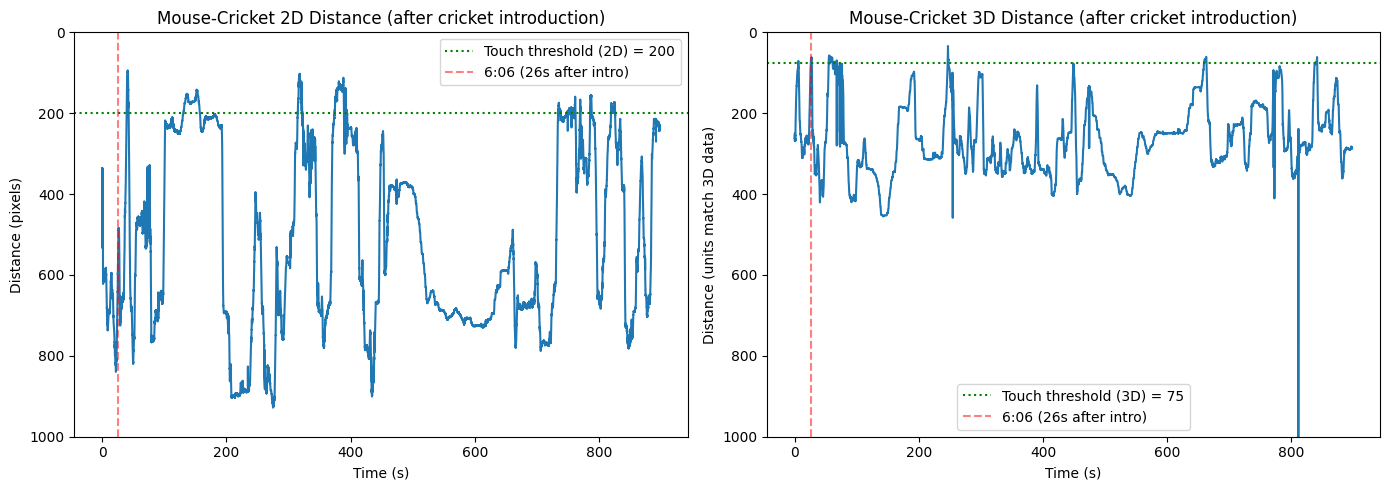

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cricket_intro_time_sec = 5 * 60 + 40  # 5 minutes 40 seconds
fps = 60  # assuming 60 fps
cricket_intro_frame = int(cricket_intro_time_sec * fps)

# Time of 6:06 is 366 seconds; cricket introduction is at 340 seconds, so 26 seconds after introduction
highlight_time_after_intro_sec = 26
highlight_frame_offset = int(highlight_time_after_intro_sec * fps)

centroid_position = get_position_centroid(data, time_slice=data.position.shape[0])
distance_mouse_cricket = get_distance_mouse_cricket(centroid_position, cricket_converted[:len(centroid_position)])

# Ensure both 2D and 3D plotted lines use the same y-limits and are properly synchronized in length
max_ylim = 1000
len_2d = len(distance_2d)
len_3d = min(len(distance_mouse_cricket), len(centroid_position))
post_intro_2d = distance_2d[cricket_intro_frame:]
post_intro_3d = distance_mouse_cricket[cricket_intro_frame:len_3d]
min_plot_len = min(len(post_intro_2d), len(post_intro_3d))
time_sec = np.arange(min_plot_len) / fps

# Touch thresholds
touch_thresh_2d = 200
touch_thresh_3d = 75

# First subplot: Mouse-Cricket 2D Distance
axes[0].plot(time_sec, post_intro_2d[:min_plot_len])
axes[0].axhline(touch_thresh_2d, color='green', linestyle=':', label=f'Touch threshold (2D) = {touch_thresh_2d}')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Distance (pixels)")
axes[0].set_title("Mouse-Cricket 2D Distance (after cricket introduction)")
axes[0].set_ylim([max_ylim, 0])  # Invert y-axis, cap outliers above 1000

# Second subplot: Mouse-Cricket 3D Distance
axes[1].plot(time_sec, post_intro_3d[:min_plot_len])
axes[1].axhline(touch_thresh_3d, color='green', linestyle=':', label=f'Touch threshold (3D) = {touch_thresh_3d}')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Distance (units match 3D data)")
axes[1].set_title("Mouse-Cricket 3D Distance (after cricket introduction)")
axes[1].set_ylim([max_ylim, 0])  # Invert y-axis, cap outliers above 1000

# Mark the 26s after introduction, which corresponds to 6:06 in the overall video
highlight_idx = highlight_frame_offset
if highlight_idx < min_plot_len:
    for ax in axes:
        ax.axvline(highlight_idx / fps, color='red', linestyle='--', label='6:06 (26s after intro)', alpha=0.5)
        ax.legend()

plt.tight_layout()
plt.show()

In [105]:
from typing import Optional
def compute_manipulation_index_paws(
    data: "xr.Dataset",
    distance_2d: np.ndarray,
    time_slice: Optional[int] = None,
    quantile_manipulation: float = 0.75,
    quantile_distance: float = 0.1,
) -> np.ndarray:
    """
    Compute manipulation index for mouse forepaws.

    Args:
        data: xr.Dataset containing the position information
        distance_2d: np.ndarray representing 2D (e.g., center-view) mouse-cricket distance
        time_slice: int or None, optional length of data to use
        quantile_manipulation: float for thresholding manipulation
        quantile_distance: float for thresholding proximity
    Returns:
        np.ndarray manipulation index (1 for close manip, -1 for far manip, 0 otherwise)
    """

    # Extract paw positions
    assert "forepaw_lf" in data.keypoints.values
    assert "forepaw_rt" in data.keypoints.values

    v_lf = data.position.sel(keypoints="forepaw_lf").values
    v_rt = data.position.sel(keypoints="forepaw_rt").values
    # v_lf and v_rt are (time, space, ...) (usually (T,3,1)), squeeze last axis if present
    v_lf = np.squeeze(v_lf, axis=-1) if v_lf.ndim == 3 and v_lf.shape[-1] == 1 else v_lf
    v_rt = np.squeeze(v_rt, axis=-1) if v_rt.ndim == 3 and v_rt.shape[-1] == 1 else v_rt
    if time_slice is not None:
        v_lf = v_lf[:time_slice]
        v_rt = v_rt[:time_slice]
        distance_2d_slice = distance_2d[:time_slice]
    else:
        distance_2d_slice = distance_2d

    # Compute body velocity (speed) using the 3D centroid
    # data.position.values shape: (time, space, keypoints)
    position_values = data.position.values  # (T, 3, K)
    centroids = np.nanmean(position_values, axis=2)  # (T, 3)
    # Ensure centroids is 2D (T, 3)
    if centroids.ndim == 3:
        # sometimes (T, 3, 1) if only one keypoint left after nanmean
        centroids = centroids.squeeze(-1)
    assert centroids.ndim == 2, f"centroids shape unexpected: {centroids.shape}"
    # vstack expects two arrays of same ndim
    body_disp = np.vstack([np.zeros((1, centroids.shape[1])), np.diff(centroids, axis=0)])
    body_speed = np.linalg.norm(body_disp, axis=1)

    # Compute paw displacements/speeds
    lf_disp = np.vstack([np.zeros((1, v_lf.shape[1])), np.diff(v_lf, axis=0)])
    rt_disp = np.vstack([np.zeros((1, v_rt.shape[1])), np.diff(v_rt, axis=0)])
    lf_speed = np.linalg.norm(lf_disp, axis=1)
    rt_speed = np.linalg.norm(rt_disp, axis=1)

    # Avoid divide-by-zero body speed
    body_speed_min = 1e-3
    body_speed_safe = np.where(body_speed > 0, body_speed, body_speed_min)
    manipulation_idx = (lf_speed / body_speed_safe + rt_speed / body_speed_safe) / 2

    manipulation_threshold = np.quantile(manipulation_idx, quantile_manipulation)
    distance_threshold = np.quantile(distance_2d_slice, quantile_distance)
    manipulation_idx_filtered = np.where(
        manipulation_idx > manipulation_threshold, manipulation_idx, 0
    )
    mask_manipulation_close = (distance_2d_slice < distance_threshold) & (
        manipulation_idx_filtered > manipulation_threshold
    )
    mask_manipulation_far = (distance_2d_slice >= distance_threshold) & (
        manipulation_idx_filtered > manipulation_threshold
    )
    manipulation_idx_filtered = np.where(
        mask_manipulation_close, 1, manipulation_idx_filtered
    )
    manipulation_idx_filtered = np.where(
        mask_manipulation_far, -1, manipulation_idx_filtered
    )
    return manipulation_idx_filtered

In [97]:
manipulation_index_paws = compute_manipulation_index_paws(data, distance_2d)

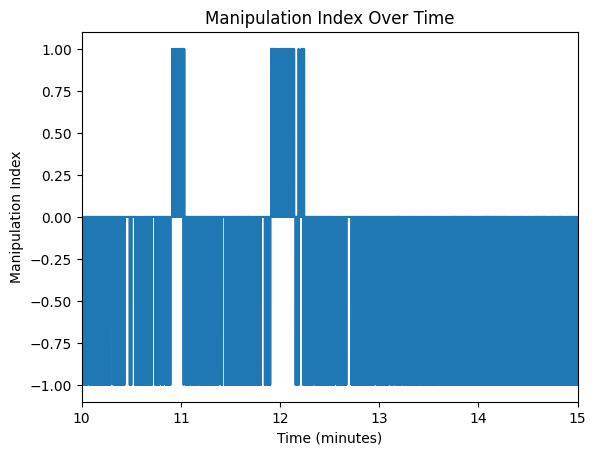

In [117]:
plt.figure()
fps = 60
n_frames = len(manipulation_index_paws)
minutes = np.arange(n_frames) / (fps * 60)
plt.plot(minutes, manipulation_index_paws)
plt.xlabel('Time (minutes)')
plt.ylabel('Manipulation Index')
plt.title('Manipulation Index Over Time')
plt.xlim(10, 15)
plt.show()


20.62611111111111

## Helpers, Filters

In [8]:
# load data from sessions:
path_sessions = Path("/Users/thomasbush/Downloads/features_all_sessions.pkl")
sessions = pickle.load(open(path_sessions, "rb"))

In [9]:
dist_mouse_cricket_extractor = sessions["multicam_video_2025-05-07T11_54_38_cropped-v2_20250701121021"]["dist_mouse_cricket"]

In [82]:
def filter_confidence_and_interpolate(
    data: xr.Dataset,
    threshold: float = 0.2,
    max_consecutive: int = 10,
    method: str = None,
    order: int = None,
) -> xr.Dataset:
    """
    Filter a xr.Dataset based on confidence and interpolate missing values.

    Args:
        data: xr.Dataset containing keypoint data
        threshold: float threshold for confidence
        max_consecutive: int maximum number of consecutive missing values to interpolate
        method: (optional) interpolation method to use (e.g., 'linear', 'polynomial', etc.)
        order: (optional) Order of interpolation (if relevant, e.g. for 'polynomial')
    Returns:
        xr.Dataset: filtered and interpolated dataset
    """
    session = data.copy()
    mask = data.confidence.values < threshold
    expanded_mask = mask[:, np.newaxis, :, :]
    session.position.values = np.where(expanded_mask, np.nan, session.position.values)

    interp_kwargs = {
        "dim": "time",
        "max_gap": max_consecutive,
    }
    if method is not None:
        interp_kwargs["method"] = method
    if order is not None:
        interp_kwargs["order"] = order

    session.position.interpolate_na(**interp_kwargs)
    return session

def apply_savgol_filter(data:xr.Dataset, window_length:int=5, polyorder:int=3)->xr.Dataset:
    """
    Apply a Savitzky-Golay filter to the data.
    """
    try:
        import xrscipy.signal as dsp
    except ImportError:
        raise ImportError("xrscipy is not installed. Please install it using `pip install xrscipy`.")
    session = data.copy()
    session.position.values = dsp.savgol_filter(session.position, window_length=window_length, polyorder=polyorder, dim="time")
    return session
def arena_filtering(
    data: xr.Dataset,
    arena_3d: xr.Dataset,
    tolerance: float = 0.0,
) -> xr.Dataset:
    """
    Filter the 3D coordinates of the animal to be inside the arena.

    Args:
        data: xr.Dataset containing a variable 'position' with dims like (frame, space, point, rep)
              where 'space' has coordinates ['x', 'y', 'z'].
        arena_3d: xr.Dataset containing 'position' with the same 'space' dimension (['x', 'y', 'z']).
        tolerance: float, margin added to the arena boundaries (in same units as position).

    Returns:
        xr.Dataset: copy of input with positions outside the arena set to NaN.
    """
    session = data.copy()
    pos = session["position"]

    # --- Get arena boundaries for each axis with tolerance ---
    x_min = arena_3d.position.sel(space="x").min() - tolerance
    x_max = arena_3d.position.sel(space="x").max() + tolerance
    y_min = arena_3d.position.sel(space="y").min() - tolerance
    y_max = arena_3d.position.sel(space="y").max() + tolerance
    z_min = arena_3d.position.sel(space="z").min() - tolerance
    z_max = arena_3d.position.sel(space="z").max() + tolerance

    # --- Extract each axis from position ---
    x = pos.sel(space="x")
    y = pos.sel(space="y")
    z = pos.sel(space="z")

    # --- Compute mask of points inside the arena ---
    inside = (
        (x >= x_min) & (x <= x_max) &
        (y >= y_min) & (y <= y_max) &
        (z >= z_min) & (z <= z_max)
    )

    # --- Apply mask (xarray broadcasts it over 'space') ---
    session["position"] = pos.where(inside, np.nan)

    return session


In [12]:
# define a funcitont to convert pose data to egocentric coordinates:
data.keypoints

<xarray.DataArray 'keypoints' (keypoints: 13)> Size: 676B
array(['back_caudal', 'back_mid', 'back_rostral', 'belly_caudal',
       'belly_rostral', 'ear_lf', 'ear_rt', 'forepaw_lf', 'forepaw_rt',
       'hindpaw_lf', 'hindpaw_rt', 'nose', 'tailbase'], dtype='<U13')
Coordinates:
  * keypoints  (keypoints) <U13 676B 'back_caudal' 'back_mid' ... 'tailbase'

In [ ]:



def normalize_ax(v, axis=1, eps=1e-8):
    norm = np.linalg.norm(v, axis=axis, keepdims=True)
    return v / np.clip(norm, eps, None)

def convert_session_to_egocentric(session:xr.Dataset):

    session_copy = session.copy()
    trunk_names = [ "back_caudal", "back_mid", "back_rostral",
    "belly_caudal", "belly_rostral",]
    origin = session.position.sel(keypoints=trunk_names).mean(dim="keypoints")
    # define the body axes:
    nose = session.position.sel(keypoints="nose").values
    tailbase = session.position.sel(keypoints="tailbase").values
    ear_lf = session.position.sel(keypoints="ear_lf").values
    ear_rt = session.position.sel(keypoints="ear_rt").values
    origin_np = origin.values
    pose_np = session.position.values

    T, C, K, A = pose_np.shape

    # forward ax
    forward = nose - tailbase
    forward = normalize_ax(forward, axis=1)
    # left ax
    left = ear_lf - ear_rt
    left = normalize_ax(left, axis=1)
    #up ax
    f = forward[..., 0]
    l = left[..., 0]
    # up= forwar X left (right hand rule)
    up = np.cross(f, l, axis=1)
    up = normalize_ax(up, axis=1)
    # recompute hte left for orthogonality
    left_2 = np.cross(up, f, axis=1)
    left_2 = normalize_ax(left_2, axis=1)
    
    ex = f
    ey = left_2
    ez = up

    # build the rotation matrices
    R = np.stack([ex, ey, ez], axis=2)
    R_T = np.transpose(R, (0, 2, 1))

    # transfrom the keypoints to egocentric
    centered = pose_np - origin_np[:, :, None, :] # broadcast over kp
    centered = centered[..., 0]
    pose_ego = np.einsum("tij, tjk -> tik", R_T, centered)# we rotate each frame p_body[t] = R_T[t] @ centered[t]
    session_copy["position"].values = np.expand_dims(pose_ego, axis=-1)
    return session_copy



In [24]:
pose_ego = convert_session_to_egocentric(data)

In [30]:
# sanity check for egocentric coordinates: numerically
# nose should be mosty positive compared to tailbase
nose_ego = pose_ego.position.sel(keypoints="nose")
tailbase_ego = pose_ego.position.sel(keypoints="tailbase")
forward_ego = nose_ego - tailbase_ego
fwd_mean = forward_ego.mean(dim=["time", "individuals"])
fwd_mean.values


array([5.57407578e+01, 7.87901679e-18, 4.86706616e-18])

In [80]:
import plotly.graph_objects as go
import numpy as np
from ipywidgets import interact, IntSlider

def plot_egocentric_pose_plotly(frame_data, edges=None, axis_len=30):
    """
    Visualize a 3D pose frame using plotly for interactivity.
    Args:
        frame_data: xarray DataSet for a single frame (isel done outside)
        edges: list of (a, b) edges to draw (optional)
        axis_len: float, axis length for body axes
    """
    frame_xyz = frame_data.position.values
    x, y, z = frame_xyz
    labels = frame_data.keypoints.values.tolist()

    if edges is None:
        edges = [
            ("tailbase", "back_caudal"),
            ("back_caudal", "back_mid"),
            ("back_mid", "back_rostral"),
            ("back_rostral", "nose"),
            ("belly_caudal", "belly_rostral"),
            ("belly_caudal", "hindpaw_lf"),
            ("belly_caudal", "hindpaw_rt"),
            ("belly_rostral", "forepaw_lf"),
            ("belly_rostral", "forepaw_rt"),
            ("back_rostral", "ear_lf"),
            ("back_rostral", "ear_rt"),
        ]
    name_to_idx = {name: i for i, name in enumerate(labels)}

    fig = go.Figure()

    # Scatter keypoints
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers+text',
        marker=dict(size=5, color='black'),
        text=labels, textposition="top center",
        name="Keypoints"
    ))

    # Draw skeleton edges
    for a, b in edges:
        if a in name_to_idx and b in name_to_idx:
            i, j = name_to_idx[a], name_to_idx[b]
            fig.add_trace(go.Scatter3d(
                x=[x[i], x[j]],
                y=[y[i], y[j]],
                z=[z[i], z[j]],
                mode='lines',
                line=dict(width=4, color="#1f77b4"),
                showlegend=False
            ))
    
    # Draw body axes from origin
    fig.add_trace(go.Scatter3d(
        x=[0, axis_len], y=[0, 0], z=[0, 0],
        mode='lines',
        line=dict(width=6, color='red'),
        name='forward (x)'
    ))
    fig.add_trace(go.Scatter3d(
        x=[0, 0], y=[0, axis_len], z=[0, 0],
        mode='lines',
        line=dict(width=6, color='green'),
        name='left (y)'
    ))
    fig.add_trace(go.Scatter3d(
        x=[0, 0], y=[0, 0], z=[0, axis_len],
        mode='lines',
        line=dict(width=6, color='blue'),
        name='up (z)'
    ))
    
    # Auto aspect and nice layout
    max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max()
    mid_x = (x.max()+x.min())/2
    mid_y = (y.max()+y.min())/2
    mid_z = (z.max()+z.min())/2
    lims = dict(
        xaxis=dict(range=[mid_x-max_range/2, mid_x+max_range/2]),
        yaxis=dict(range=[mid_y-max_range/2, mid_y+max_range/2]),
        zaxis=dict(range=[mid_z-max_range/2, mid_z+max_range/2])
    )

    fig.update_layout(
        scene=dict(
            xaxis_title="forward (x)",
            yaxis_title="left (y)",
            zaxis_title="up (z)",
            xaxis=lims["xaxis"],
            yaxis=lims["yaxis"],
            zaxis=lims["zaxis"],
            aspectmode='cube',
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        legend=dict(x=0, y=0.9)
    )
    frame_idx = None
    if hasattr(frame_data, "get_index") and "time" in frame_data.coords:
        frame_idx = int(frame_data.time.values)
    title = f"Egocentric pose – frame {frame_idx}" if frame_idx is not None else "Egocentric pose (frame)"
    fig.update_layout(title=title)
    fig.show()

def show_egocentric_frame_interactive_plotly(pose_ego, individual=0):
    """
    Interactive widget to scroll through time of egocentric pose, using plotly.
    Args:
        pose_ego: xarray Dataset with .position (shape: time x keypoint x 3)
        individual: int, which individual to visualize
    """
    max_frame_idx = pose_ego.sizes["time"] - 1
    def _plotly(frame_idx):
        frame = pose_ego.isel(time=frame_idx, individuals=individual)
        plot_egocentric_pose_plotly(frame)
    interact(_plotly, frame_idx=IntSlider(min=0, max=max_frame_idx, step=1, value=0, description="Frame"))

# Usage: Explore frames with scroll, drag, and zoom via mouse/trackpad in plotly plot!
# show_egocentric_frame_interactive_plotly(pose_ego)

In [ ]:
# let's see the egocentric plot after the savgol filter:
pose_ego_savgol = apply_savgol_filter(pose_ego, window_length=10, polyorder=5)

show_egocentric_frame_interactive_plotly(pose_ego_savgol)

interactive(children=(IntSlider(value=0, description='Frame', max=74268), Output()), _dom_classes=('widget-int…